<a href="https://colab.research.google.com/github/Adr1an12/retail-fraud-detection-ml/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Manipulação dos dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelos supervisionados
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Detecção de anomalias
from sklearn.ensemble import IsolationForest

# Métricas
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# Configuração dos gráficos
plt.style.use("ggplot")
sns.set_theme()

In [4]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("/content/retail_fraud_detection_100k.csv")

df.head()

Saving retail_fraud_detection_100k.csv to retail_fraud_detection_100k.csv


,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,T0000001,C20953,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,...,4,1054,0,0,0,1,0,1,0,Medium
1,T0000002,C24133,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,...,2,97,0,0,0,0,0,0,0,Low
2,T0000003,C07165,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,...,4,779,1,0,0,0,0,0,0,Medium
3,T0000004,C19310,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,...,3,286,1,1,0,1,0,1,1,High
4,T0000005,C25019,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,...,3,866,0,0,0,1,0,0,0,Low


In [5]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

df.info()

Linhas: 100000
Colunas: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   transaction_id                    100000 non-null  object 
 1   customer_id                       100000 non-null  object 
 2   transaction_timestamp             100000 non-null  object 
 3   transaction_amount                100000 non-null  float64
 4   payment_method                    100000 non-null  object 
 5   device_type                       100000 non-null  object 
 6   location                          100000 non-null  object 
 7   merchant_category                 100000 non-null  object 
 8   is_international                  100000 non-null  int64  
 9   transaction_frequency_24h         100000 non-null  int64  
 10  avg_transaction_amount_7d         100000 non-null  float64
 11  failed_transaction_count_2

In [6]:
df.describe(include="all")

,transaction_id,customer_id,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,...,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
count,100000,100000,100000,100000.000000,100000,100000,100000,100000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000
unique,100000,28955,100000,NaN,5,3,6,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,T0099984,C00353,2025-08-31 19:56:25.768710,NaN,Apple Pay,Mobile,Germany,Fashion,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium
freq,1,13,1,NaN,20098,33454,16759,16893,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52211
mean,NaN,NaN,NaN,120.475407,NaN,NaN,NaN,NaN,0.498010,7.489910,...,2.003560,1005.329380,0.500150,0.229530,0.498010,0.427040,0.100960,0.283980,0.475080,NaN
std,NaN,NaN,NaN,119.787252,NaN,NaN,NaN,NaN,0.499999,4.024028,...,1.414923,573.313726,0.500002,0.420533,0.499999,0.494651,0.301277,0.450929,0.499381,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,1.000000,...,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,34.820000,NaN,NaN,NaN,NaN,0.000000,4.000000,...,1.000000,510.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,84.130000,NaN,NaN,NaN,NaN,0.000000,7.000000,...,2.000000,1004.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,167.520000,NaN,NaN,NaN,NaN,1.000000,11.000000,...,3.000000,1501.250000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,NaN


transaction_id                      0
customer_id                         0
transaction_timestamp               0
transaction_amount                  0
payment_method                      0
device_type                         0
location                            0
merchant_category                   0
is_international                    0
transaction_frequency_24h           0
avg_transaction_amount_7d           0
failed_transaction_count_24h        0
account_age_days                    0
previous_fraud_flag                 0
unusual_amount_flag                 0
unusual_location_flag               0
multiple_transactions_short_time    0
high_risk_device_flag               0
velocity_flag                       0
fraud_flag                          0
fraud_risk                          0
dtype: int64


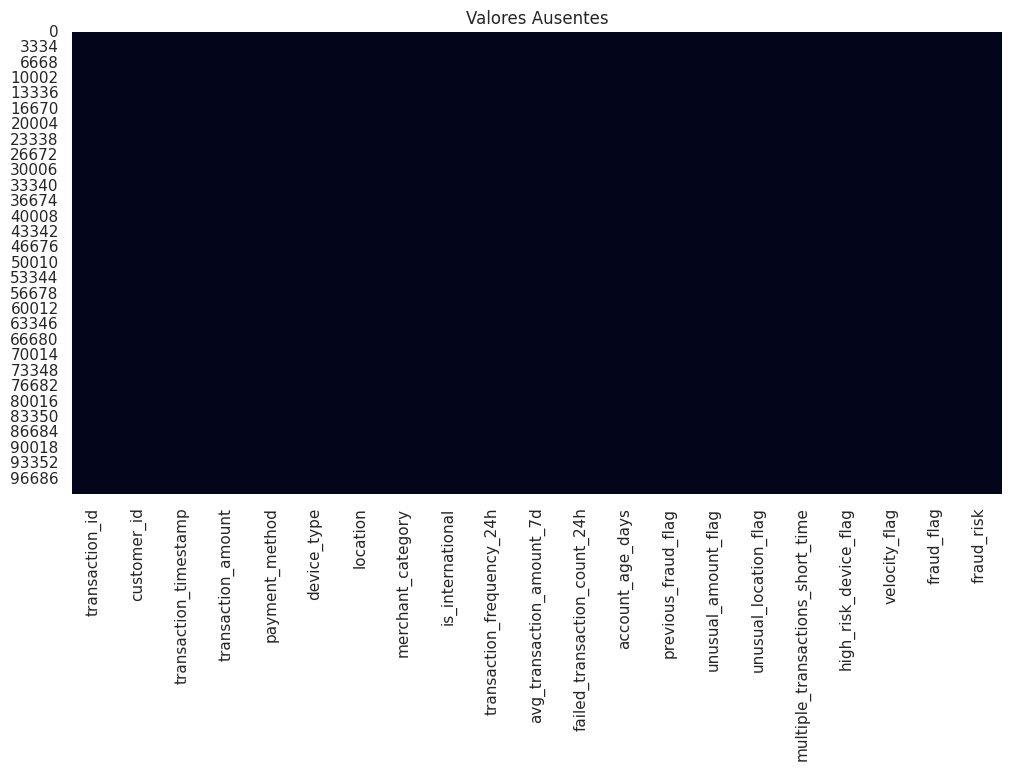

In [7]:
print(df.isnull().sum())
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Valores Ausentes")

plt.show()

In [8]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


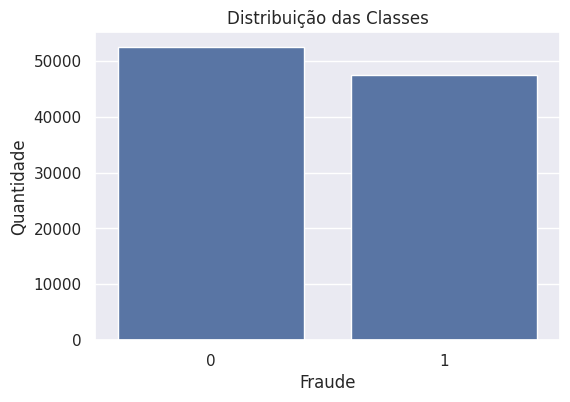

fraud_flag
0    52492
1    47508
Name: count, dtype: int64

Percentual:
fraud_flag
0    52.492
1    47.508
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="fraud_flag")

plt.title("Distribuição das Classes")
plt.xlabel("Fraude")
plt.ylabel("Quantidade")

plt.show()

print(df["fraud_flag"].value_counts())

print("\nPercentual:")

print(df["fraud_flag"].value_counts(normalize=True)*100)

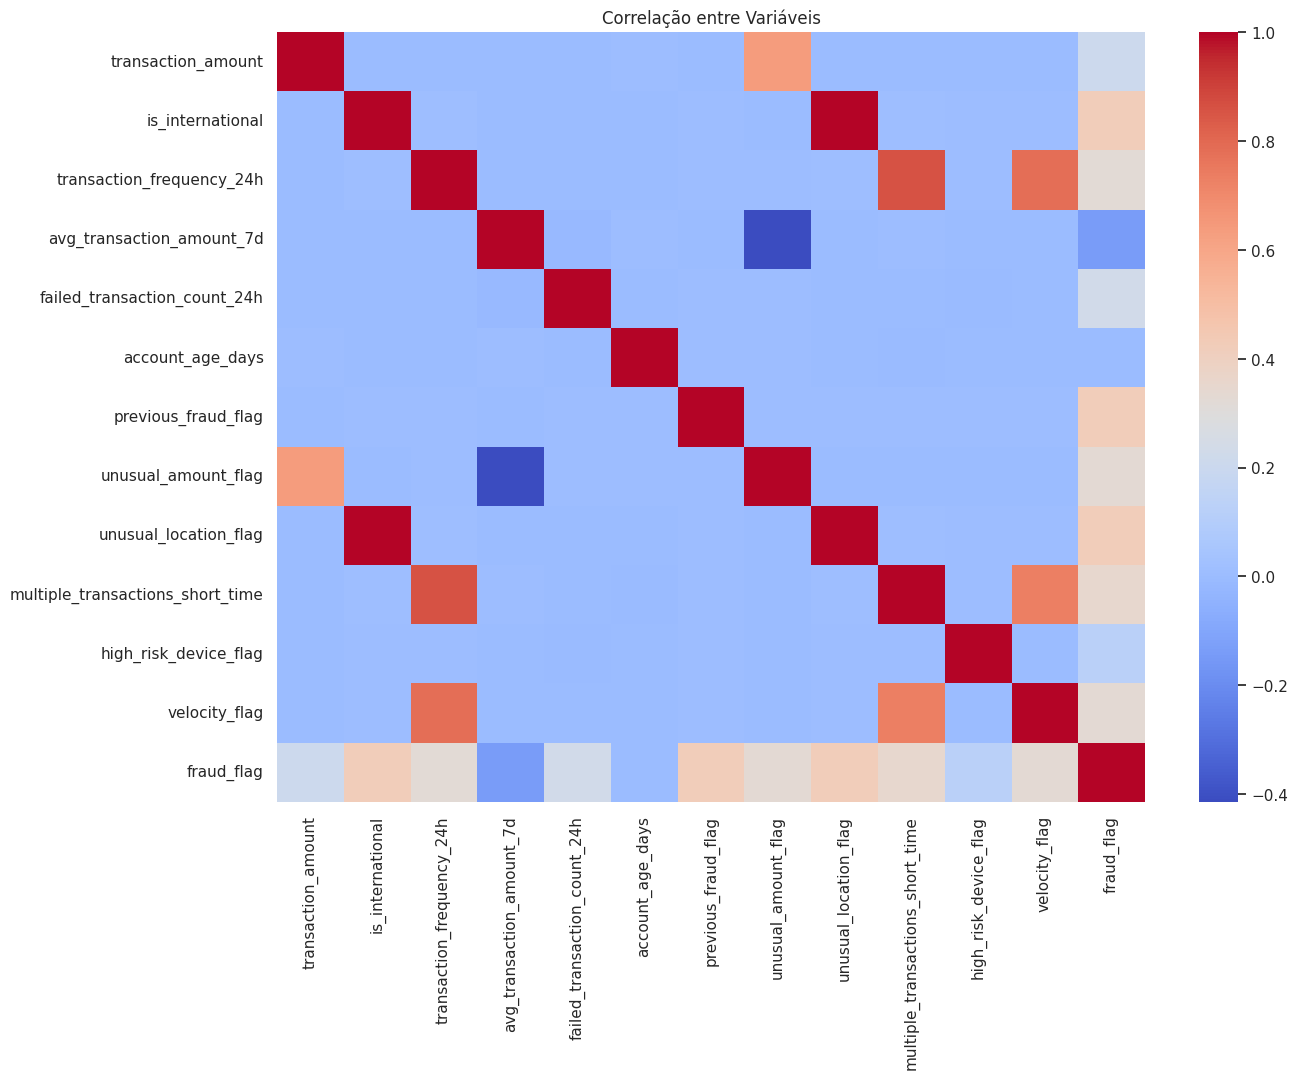

In [10]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlação entre Variáveis")

plt.show()

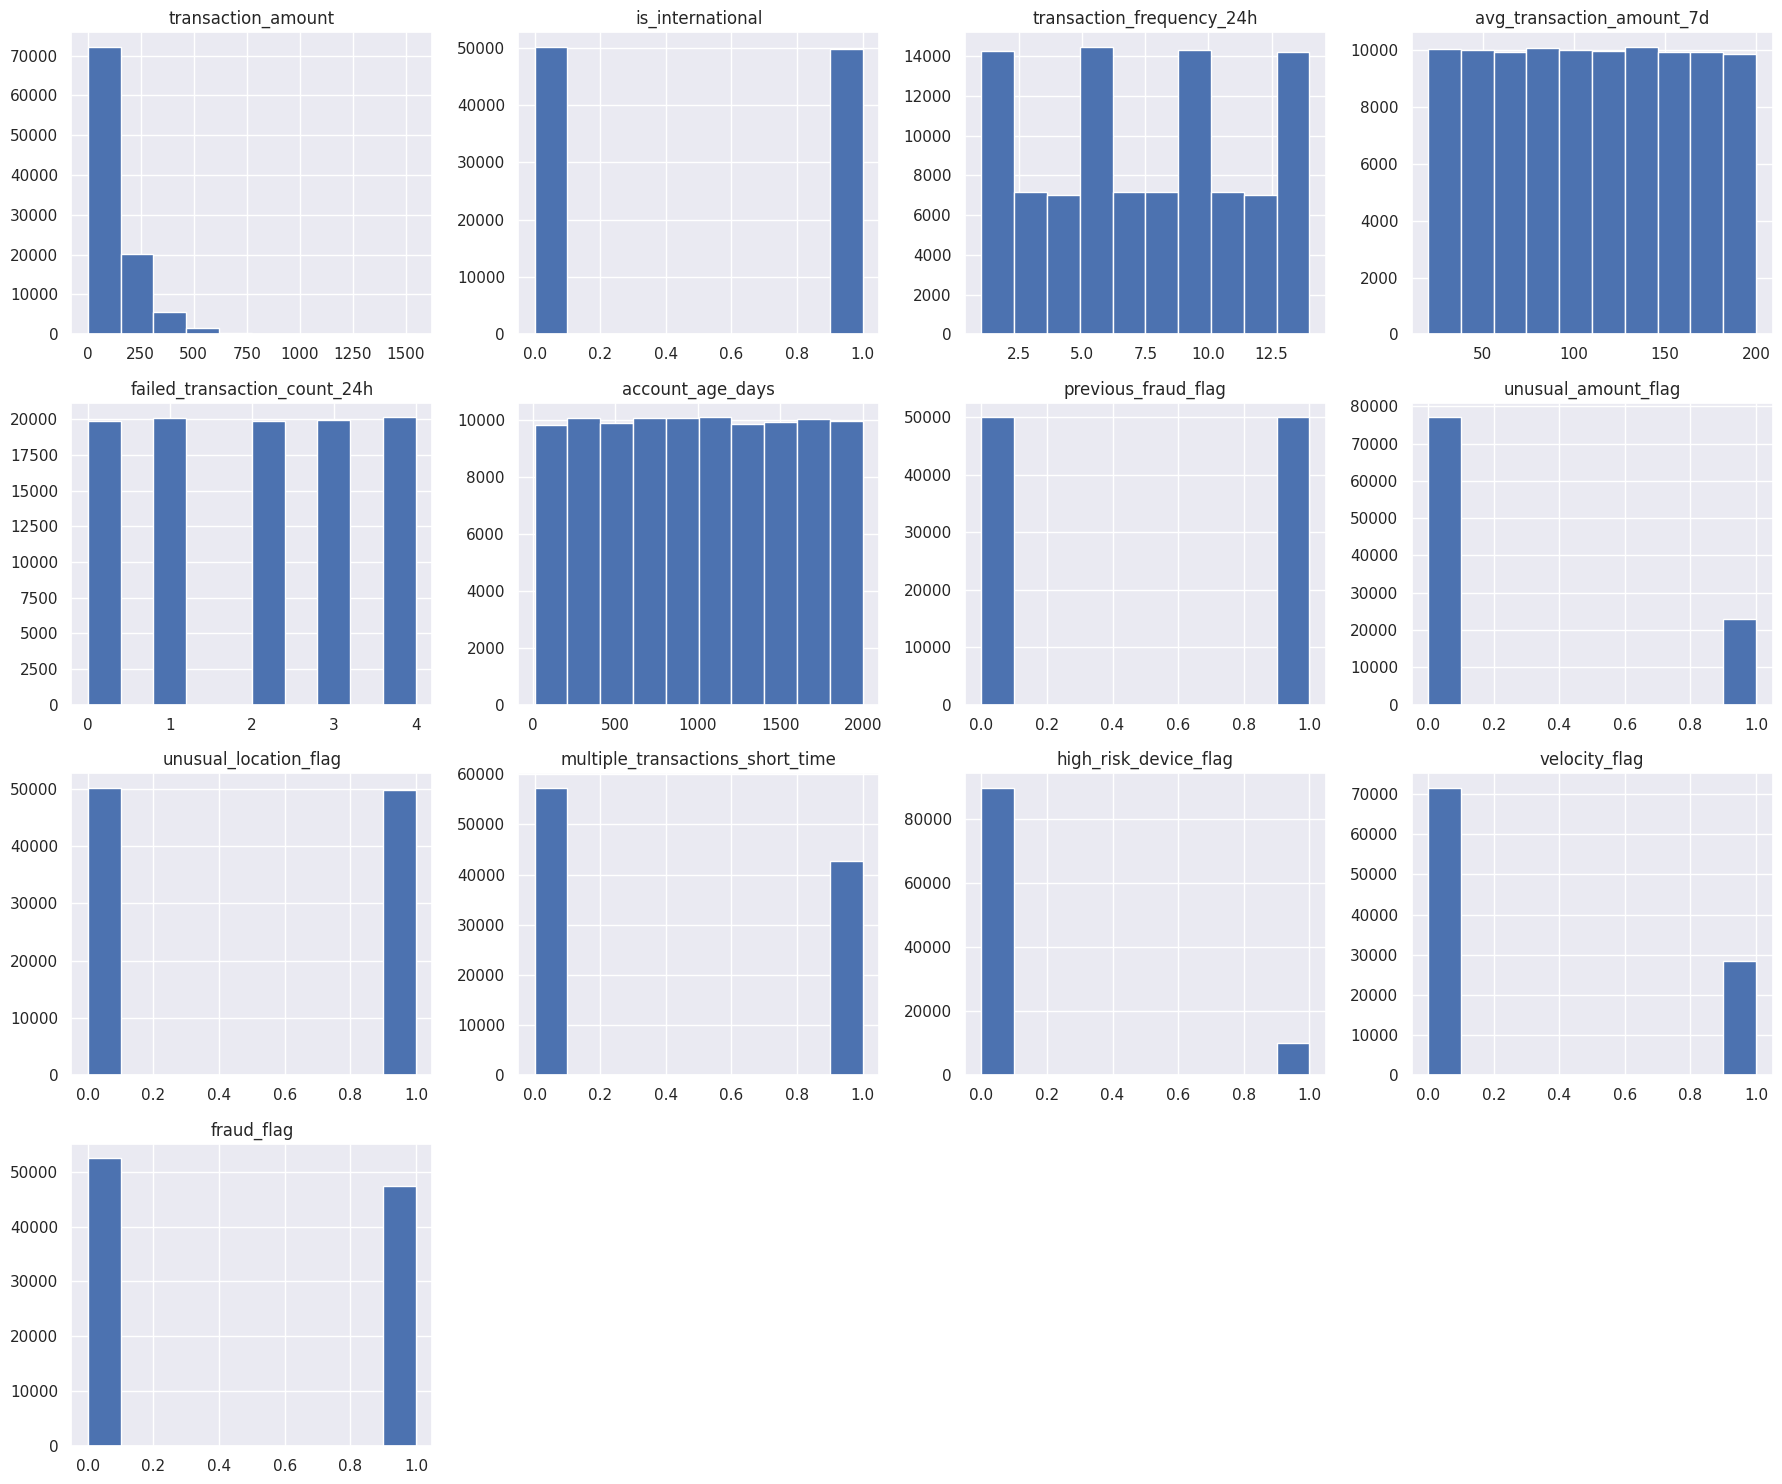

In [11]:
df.hist(figsize=(18,15))

plt.tight_layout()

plt.show()

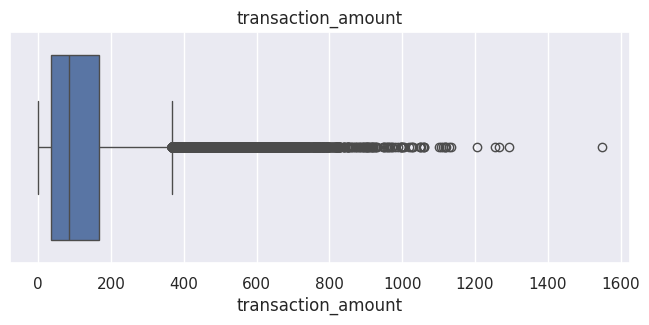

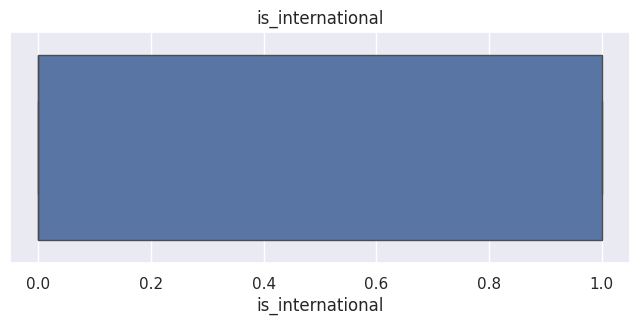

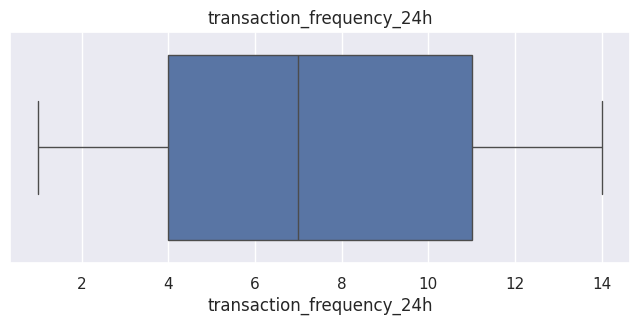

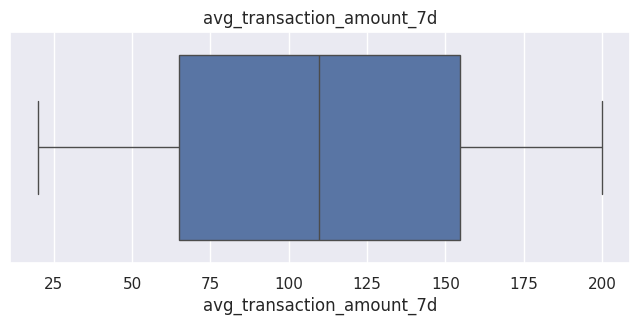

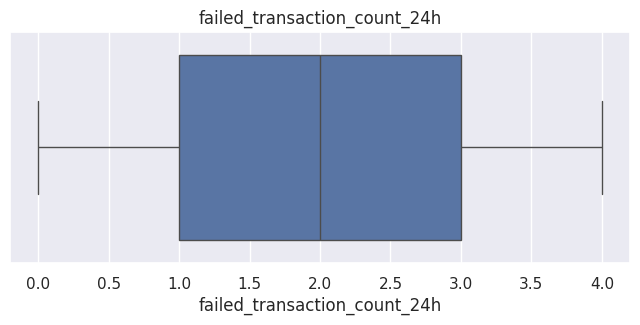

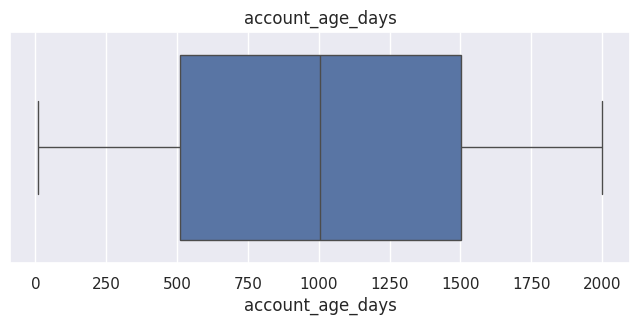

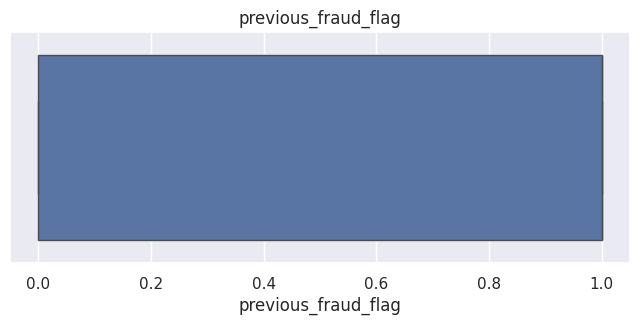

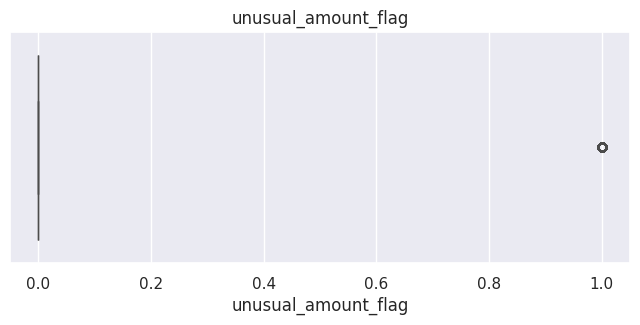

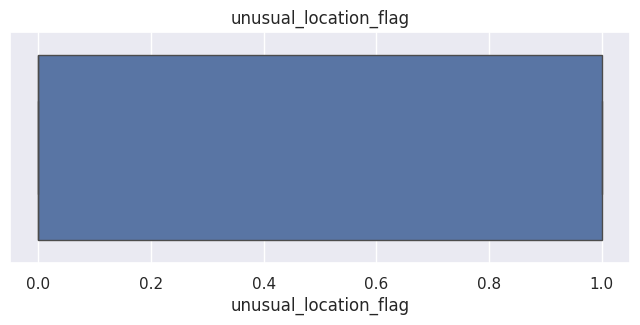

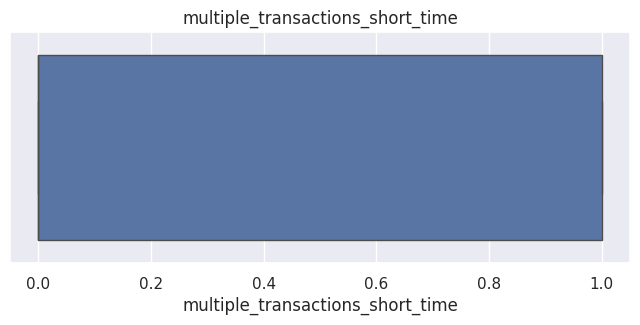

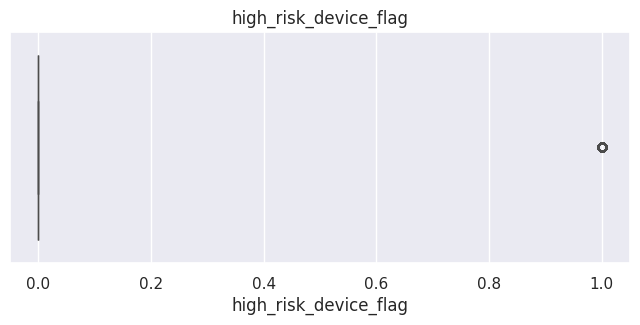

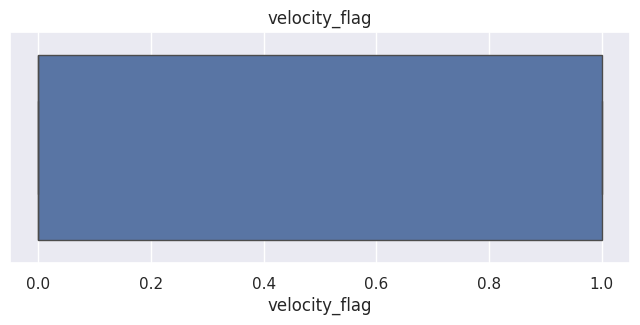

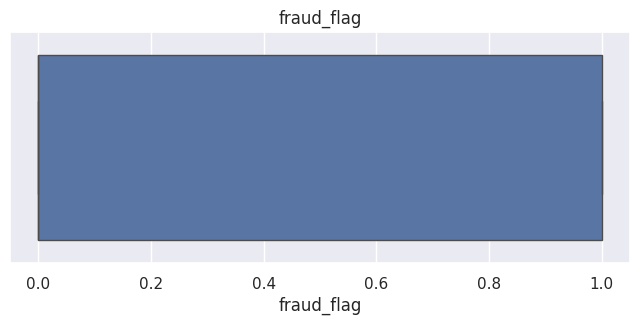

In [12]:
colunas = df.select_dtypes(include="number").columns

for coluna in colunas:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[coluna])

    plt.title(coluna)

    plt.show()

In [13]:
df = df.drop(columns=["transaction_id", "customer_id"])

df.head()

,transaction_timestamp,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,previous_fraud_flag,unusual_amount_flag,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk
0,2026-03-04 19:56:23.679173,56.31,Debit Card,Tablet,Canada,Fashion,0,13,53.02,4,1054,0,0,0,1,0,1,0,Medium
1,2026-03-09 19:56:23.679330,20.35,Credit Card,Tablet,India,Electronics,0,3,38.00,2,97,0,0,0,0,0,0,0,Low
2,2026-01-01 19:56:23.679362,48.72,Debit Card,Tablet,UK,Travel,0,8,147.45,4,779,1,0,0,0,0,0,0,Medium
3,2025-12-09 19:56:23.679385,153.62,Debit Card,Mobile,Australia,Fashion,0,14,58.22,3,286,1,1,0,1,0,1,1,High
4,2025-11-09 19:56:23.679409,115.32,PayPal,Mobile,India,Gaming,0,10,114.46,3,866,0,0,0,1,0,0,0,Low


In [14]:
df["transaction_timestamp"] = pd.to_datetime(df["transaction_timestamp"])

df["ano"] = df["transaction_timestamp"].dt.year
df["mes"] = df["transaction_timestamp"].dt.month
df["dia"] = df["transaction_timestamp"].dt.day
df["hora"] = df["transaction_timestamp"].dt.hour

df = df.drop(columns=["transaction_timestamp"])

df.head()

,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,...,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,ano,mes,dia,hora
0,56.31,Debit Card,Tablet,Canada,Fashion,0,13,53.02,4,1054,...,0,1,0,1,0,Medium,2026,3,4,19
1,20.35,Credit Card,Tablet,India,Electronics,0,3,38.00,2,97,...,0,0,0,0,0,Low,2026,3,9,19
2,48.72,Debit Card,Tablet,UK,Travel,0,8,147.45,4,779,...,0,0,0,0,0,Medium,2026,1,1,19
3,153.62,Debit Card,Mobile,Australia,Fashion,0,14,58.22,3,286,...,0,1,0,1,1,High,2025,12,9,19
4,115.32,PayPal,Mobile,India,Gaming,0,10,114.46,3,866,...,0,1,0,0,0,Low,2025,11,9,19


In [15]:
categoricas = df.select_dtypes(include="object").columns

print(categoricas)

Index(['payment_method', 'device_type', 'location', 'merchant_category',
       'fraud_risk'],
      dtype='object')


In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for coluna in categoricas:
    df[coluna] = encoder.fit_transform(df[coluna])

df.head()

,transaction_amount,payment_method,device_type,location,merchant_category,is_international,transaction_frequency_24h,avg_transaction_amount_7d,failed_transaction_count_24h,account_age_days,...,unusual_location_flag,multiple_transactions_short_time,high_risk_device_flag,velocity_flag,fraud_flag,fraud_risk,ano,mes,dia,hora
0,56.31,2,2,1,1,0,13,53.02,4,1054,...,0,1,0,1,0,2,2026,3,4,19
1,20.35,1,2,3,0,0,3,38.00,2,97,...,0,0,0,0,0,1,2026,3,9,19
2,48.72,2,2,4,5,0,8,147.45,4,779,...,0,0,0,0,0,2,2026,1,1,19
3,153.62,2,1,0,1,0,14,58.22,3,286,...,0,1,0,1,1,0,2025,12,9,19
4,115.32,4,1,3,2,0,10,114.46,3,866,...,0,1,0,0,0,1,2025,11,9,19


In [17]:
X = df.drop(columns=["fraud_flag"])

y = df["fraud_flag"]

print(X.shape)
print(y.shape)

(100000, 21)
(100000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (80000, 21)
Teste : (20000, 21)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:
print("Treino:", X_train.shape)

print("Teste :", X_test.shape)

print("Classes de treino")

print(y_train.value_counts())

print("\nClasses de teste")

print(y_test.value_counts())

Treino: (80000, 21)
Teste : (20000, 21)
Classes de treino
fraud_flag
0    41994
1    38006
Name: count, dtype: int64

Classes de teste
fraud_flag
0    10498
1     9502
Name: count, dtype: int64


In [21]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(random_state=42)

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

prob_lr = modelo_lr.predict_proba(X_test)[:,1]

In [22]:
print("===== REGRESSÃO LOGÍSTICA =====")

print(classification_report(y_test, pred_lr))

print("Accuracy :", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall   :", recall_score(y_test, pred_lr))
print("F1-score :", f1_score(y_test, pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, prob_lr))

===== REGRESSÃO LOGÍSTICA =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10498
           1       1.00      1.00      1.00      9502

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0


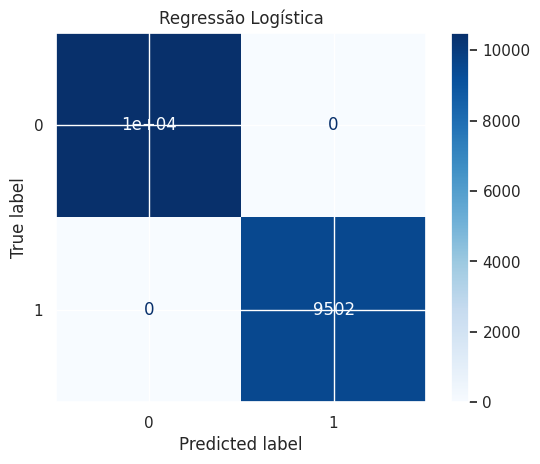

In [23]:
cm = confusion_matrix(y_test, pred_lr)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Regressão Logística")

plt.show()

In [24]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = DecisionTreeClassifier(
    random_state=42
)

modelo_dt.fit(X_train, y_train)

pred_dt = modelo_dt.predict(X_test)

prob_dt = modelo_dt.predict_proba(X_test)[:,1]

In [25]:
print("===== ÁRVORE DE DECISÃO =====")

print(classification_report(y_test, pred_dt))

print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision:", precision_score(y_test, pred_dt))
print("Recall   :", recall_score(y_test, pred_dt))
print("F1-score :", f1_score(y_test, pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, prob_dt))

===== ÁRVORE DE DECISÃO =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10498
           1       1.00      1.00      1.00      9502

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
ROC-AUC  : 1.0


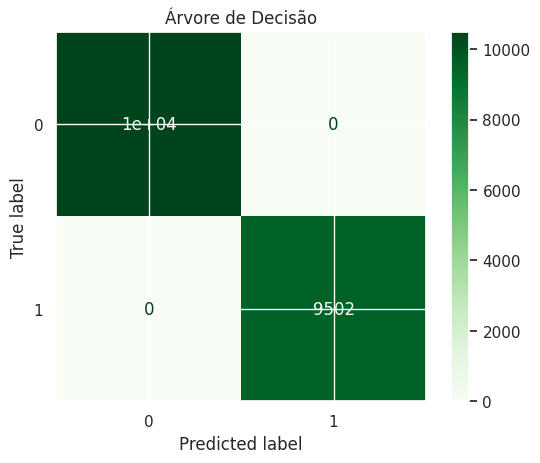

In [26]:
cm = confusion_matrix(y_test, pred_dt)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Greens")

plt.title("Árvore de Decisão")

plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

prob_rf = modelo_rf.predict_proba(X_test)[:,1]

In [28]:
print("===== RANDOM FOREST =====")

print(classification_report(y_test, pred_rf))

print("Accuracy :", accuracy_score(y_test, pred_rf))
print("Precision:", precision_score(y_test, pred_rf))
print("Recall   :", recall_score(y_test, pred_rf))
print("F1-score :", f1_score(y_test, pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, prob_rf))

===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     10498
           1       1.00      1.00      1.00      9502

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

Accuracy : 0.99995
Precision: 0.9998947700726086
Recall   : 1.0
F1-score : 0.9999473822678242
ROC-AUC  : 1.0


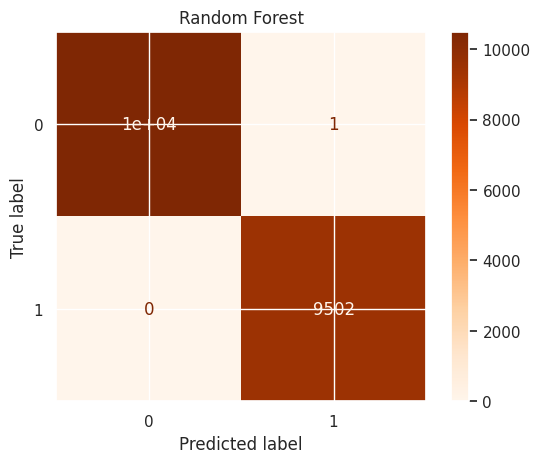

In [29]:
cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Oranges")

plt.title("Random Forest")

plt.show()

In [30]:
resultados = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ],
    "Precision": [
        precision_score(y_test, pred_lr),
        precision_score(y_test, pred_dt),
        precision_score(y_test, pred_rf)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, prob_lr),
        roc_auc_score(y_test, prob_dt),
        roc_auc_score(y_test, prob_rf)
    ]
})

resultados.sort_values(by="F1-score", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Regressão Logística,1.00000,1.000000,1.0,1.000000,1.0
1,Árvore de Decisão,1.00000,1.000000,1.0,1.000000,1.0
2,Random Forest,0.99995,0.999895,1.0,0.999947,1.0


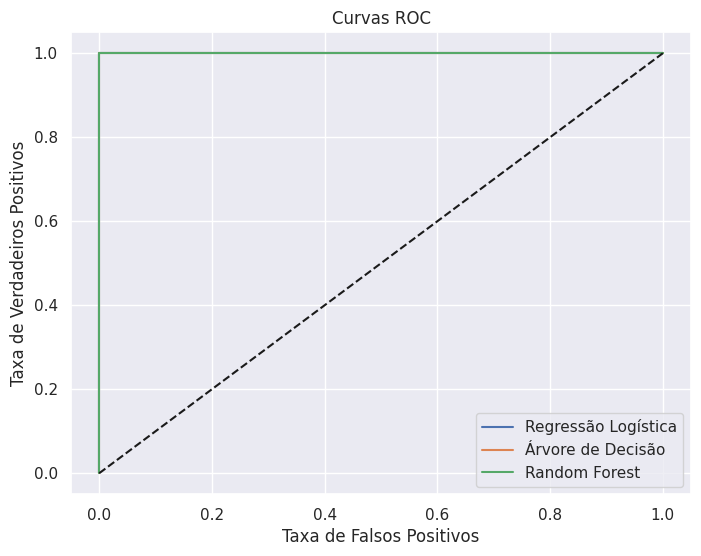

In [31]:
plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

plt.plot(fpr_lr, tpr_lr, label="Regressão Logística")
plt.plot(fpr_dt, tpr_dt, label="Árvore de Decisão")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("Taxa de Falsos Positivos")

plt.ylabel("Taxa de Verdadeiros Positivos")

plt.title("Curvas ROC")

plt.legend()

plt.show()

In [32]:
from sklearn.ensemble import IsolationForest

modelo_if = IsolationForest(
    contamination=y_train.mean(),
    random_state=42
)

modelo_if.fit(X_train)

IsolationForest(contamination=np.float64(0.475075), random_state=42)

In [33]:
pred_if = modelo_if.predict(X_test)

pred_if = np.where(pred_if == -1, 1, 0)

In [34]:
print("===== ISOLATION FOREST =====")

print(classification_report(y_test, pred_if))

print("Accuracy :", accuracy_score(y_test, pred_if))
print("Precision:", precision_score(y_test, pred_if))
print("Recall   :", recall_score(y_test, pred_if))
print("F1-score :", f1_score(y_test, pred_if))

===== ISOLATION FOREST =====
              precision    recall  f1-score   support

           0       0.68      0.67      0.68     10498
           1       0.64      0.65      0.65      9502

    accuracy                           0.66     20000
   macro avg       0.66      0.66      0.66     20000
weighted avg       0.66      0.66      0.66     20000

Accuracy : 0.6635
Precision: 0.6438057688317078
Recall   : 0.6530204167543675
F1-score : 0.648380355276907


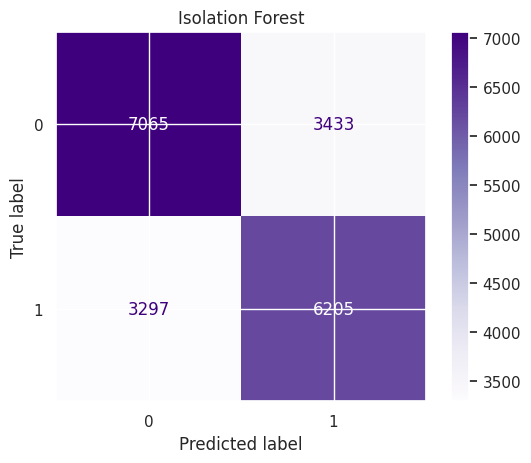

In [35]:
cm = confusion_matrix(y_test, pred_if)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Purples")

plt.title("Isolation Forest")

plt.show()

In [36]:
comparacao = pd.DataFrame({
    "Modelo":[
        "Regressão Logística",
        "Árvore de Decisão",
        "Random Forest",
        "Isolation Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_if)
    ],
    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_dt),
        precision_score(y_test,pred_rf),
        precision_score(y_test,pred_if)
    ],
    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_dt),
        recall_score(y_test,pred_rf),
        recall_score(y_test,pred_if)
    ],
    "F1-score":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_dt),
        f1_score(y_test,pred_rf),
        f1_score(y_test,pred_if)
    ]
})

comparacao = comparacao.sort_values(
    by="F1-score",
    ascending=False
)

comparacao

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regressão Logística,1.00000,1.000000,1.00000,1.000000
1,Árvore de Decisão,1.00000,1.000000,1.00000,1.000000
2,Random Forest,0.99995,0.999895,1.00000,0.999947
3,Isolation Forest,0.66350,0.643806,0.65302,0.648380


In [37]:
melhor = comparacao.iloc[0]

print("Melhor modelo encontrado:")

print(melhor)

Melhor modelo encontrado:
Modelo       Regressão Logística
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1-score                     1.0
Name: 0, dtype: object


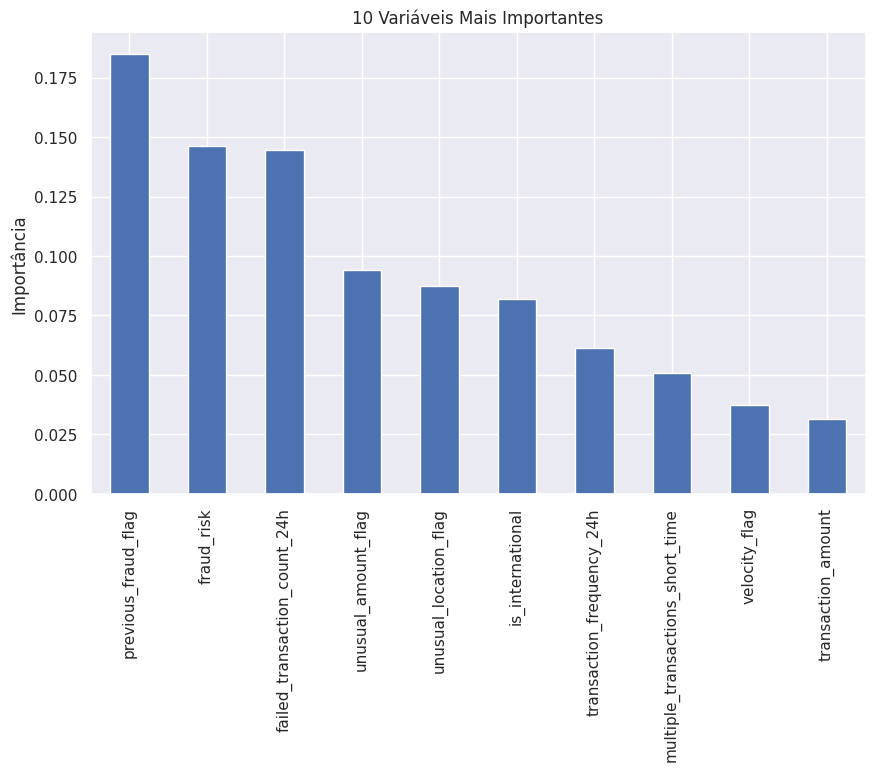

In [38]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importancias.head(10).plot(kind="bar")

plt.title("10 Variáveis Mais Importantes")

plt.ylabel("Importância")

plt.show()